In [1]:
# 1. Install everything silently
!pip install -q msprime tskit demes demesdraw

# 2. Force a path refresh
import site
from importlib import reload
reload(site)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.0 MB/s eta 0:00:00


<module 'site' (frozen)>

Let's implement the model below in msprime.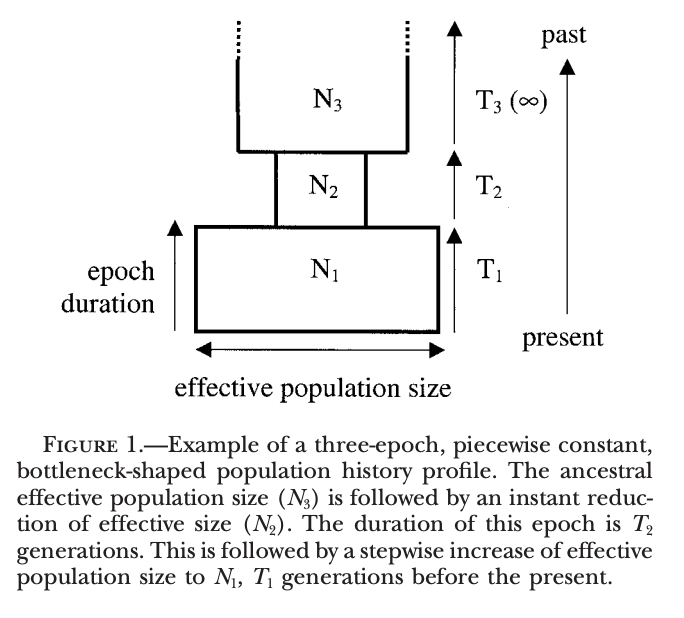

In [2]:
import msprime
#import pyslim
import demesdraw
import numpy as np
import tskit
import matplotlib.pyplot as plt

In [23]:
# Set Parameters for the selection coefficient of 0.75%
NREF = 10000
LEN = 80000
MU = 1.5e-8
RHO = 1e-8
SEL = 0.0075 # 0.75%
NCHROMS = 198
SELPOS = 40000

# Initialise a demography without events (just selection)
demog_p1 = msprime.Demography()
demog_p1.add_population(name="European", initial_size=20000)

# Run the Sweep
sweep_model = msprime.SweepGenicSelection(
    position=SELPOS,
    start_frequency=0.01,
    end_frequency=0.6,
    s=SEL,
    dt=float(1.0 / (40 * NREF))
)

ts_sweep = msprime.sim_ancestry(
    samples=NCHROMS,
    sequence_length=LEN,
    recombination_rate=RHO,
    demography=demog_p1, # Use the simple demography here
    model=sweep_model,
)

# DEMOGRAPHY: Now you do the full 3-epoch model
# The name "European" now matches Phase 1 exactly.
demog_p2 = msprime.Demography()
demog_p2.add_population(name="European", initial_size=20000)
demog_p2.add_population_parameters_change(time=3000, initial_size=2000)
demog_p2.add_population_parameters_change(time=3500, initial_size=10000)

ts_final = msprime.sim_ancestry(
    initial_state=ts_sweep,
    demography=demog_p2,
    recombination_rate=RHO,
    sequence_length=LEN,
    random_seed=42
)

mutated_ts = msprime.sim_mutations(
    ts_final,
    rate=MU,
    discrete_genome=False,
    model=msprime.BinaryMutationModel(),
)

# Output resulting sites and mutations
print("Resulting Sites: ")
print(len(mutated_ts.sites()))
print("Resulting Mutations: ")
for variant in mutated_ts.variants():
    print(f"Position: {variant.site.position:.2f}, Alleles: {variant.alleles}, Genotypes: {variant.genotypes}")

Resulting Sites: 
373
Resulting Mutations: 
Position: 2.44, Alleles: ('0', '1'), Genotypes: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Position: 107.43, Alleles: ('0', '1'), Genotypes: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [17]:
# Set Parameters for the selection coefficient of 1.5%
NREF = 10000
LEN = 80000
MU = 1.5e-8
RHO = 1e-8
SEL = 0.015 # 1.5%
FREQ = 1.0   # Fixed at present
NCHROMS = 198
SELPOS = 40000

# Initialise a demography without events (just selection)
demog_p1 = msprime.Demography()
demog_p1.add_population(name="European", initial_size=20000)

# Run the Sweep
sweep_model = msprime.SweepGenicSelection(
    position=SELPOS,
    start_frequency=0.01,
    end_frequency=0.9999,
    s=SEL,
    dt=float(1.0 / (40 * NREF))
)

ts_sweep = msprime.sim_ancestry(
    samples=NCHROMS,
    sequence_length=LEN,
    recombination_rate=RHO,
    demography=demog_p1, # Use the simple demography here
    model=sweep_model,
)

# DEMOGRAPHY: Now you do the full 3-epoch model
# The name "European" now matches Phase 1 exactly.
demog_p2 = msprime.Demography()
demog_p2.add_population(name="European", initial_size=20000)
demog_p2.add_population_parameters_change(time=3000, initial_size=2000)
demog_p2.add_population_parameters_change(time=3500, initial_size=10000)

ts_final = msprime.sim_ancestry(
    initial_state=ts_sweep,
    demography=demog_p2,
    recombination_rate=RHO,
    sequence_length=LEN,
    random_seed=42
)

mutated_ts = msprime.sim_mutations(
    ts_final,
    rate=MU,
    discrete_genome=False,
    model=msprime.BinaryMutationModel(),
)

# Output resulting sites and mutations
print("Resulting Sites: ")
print(len(mutated_ts.sites()))
print("Resulting Mutations: ")
for variant in mutated_ts.variants():
    print(f"Position: {variant.site.position:.2f}, Alleles: {variant.alleles}, Genotypes: {variant.genotypes}")

Resulting Sites: 
388
Resulting Mutations: 
Position: 193.35, Alleles: ('0', '1'), Genotypes: [0 1 1 0 1 1 1 1 0 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1
 1 1 0 0 1 1 1 1 0 0 0 0 1 0 1 1 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 1
 1 1 1 0 1 0 0 0 1 0 1 0 1 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 1 1 0 0 1 1 0
 1 0 0 1 0 1 1 0 0 1 1 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0
 0 0 1 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 1 0
 0 0 0 0 1 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1
 0 0 0 1 0 0 1 0 0 0 1 1 1 0 1 0 1 1 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 0 1 1 1
 1 1 0 1 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 0 1 0 1 1 0 0 1 0 1 1 1 0 1 1 0 1 0
 0 1 1 0 1 1 0 0 1 1 0 0 0 0 1 1 1 0 1 0 1 1 0 0 0 1 0 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 1 1
 0 0 1 1 0 0 0 1 1 1 0 0 1 0 0 1 0 1 1 0 0 1 1 0 0 1]
Position: 314.57, Alleles: ('0', '1'), Genotypes: [0 0 1 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 1 1 1 0 1 1 0

In [21]:
# Now do a neutral simulation to compare.
NREF = 10000
LEN = 80000
MU = 1.5e-8
RHO = 1e-8
SEL = 0.0075 # 1.5%
FREQ = 1.0   # Fixed at present
NCHROMS = 198
SELPOS = 40000

# DEMOGRAPHY: Now you do the full 3-epoch model
# The name "European" now matches Phase 1 exactly.
demog_p2 = msprime.Demography()
demog_p2.add_population(name="European", initial_size=20000)
demog_p2.add_population_parameters_change(time=3000, initial_size=2000)
demog_p2.add_population_parameters_change(time=3500, initial_size=10000)

ts_final = msprime.sim_ancestry(
    samples=NCHROMS,
    demography=demog_p2,
    recombination_rate=RHO,
    sequence_length=LEN,
    random_seed=42
)

mutated_ts = msprime.sim_mutations(
    ts_final,
    rate=MU,
    discrete_genome=False,
    model=msprime.BinaryMutationModel(),
)

# Output resulting sites and mutations
print("Resulting Sites: ")
print(len(mutated_ts.sites()))
print("Resulting Mutations: ")
for variant in mutated_ts.variants():
    print(f"Position: {variant.site.position:.2f}, Alleles: {variant.alleles}, Genotypes: {variant.genotypes}")

Resulting Sites: 
400
Resulting Mutations: 
Position: 268.58, Alleles: ('0', '1'), Genotypes: [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Position: 428.36, Alleles: ('0', '1'), Genotypes: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0